Smearing Matrix and Effective Area
===

The tutorial shows how to access instrument response functions in the form of smearing matrices and effective areas from IceCube 14-year public data release using SkyLLH. 

In [1]:
import sys

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

sys.path.append('/Users/amithan/skyllh_14/skyllh')

Here we start by importing the helper class ``PDSmearingMatrix``. This class provides the user all the necessary tools to be able to access the smearing matrix realted to the chosen detector configuration. 

In [2]:
from skyllh.analyses.i3.publicdata_ps.smearing_matrix import PDSmearingMatrix

In [25]:
help(PDSmearingMatrix)

Help on class PDSmearingMatrix in module skyllh.analyses.i3.publicdata_ps.smearing_matrix:

class PDSmearingMatrix(builtins.object)
 |  PDSmearingMatrix(pathfilenames, **kwargs)
 |  
 |  This class is a helper class for dealing with the smearing matrix
 |  provided by the public data.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, pathfilenames, **kwargs)
 |      Creates a smearing matrix instance by loading the smearing matrix
 |      from the given file.
 |  
 |  get_ang_err_idx(self, true_e_idx, true_dec_idx, reco_e_idx, psi_idx, ang_err)
 |      Returns the bin index for the given angular error value given the
 |      true energy, true declination, reco energy, and psi bin indices.
 |      
 |      Parameters
 |      ----------
 |      true_e_idx : int
 |          The index of the true energy bin.
 |      true_dec_idx : int
 |          The index of the true declination bin.
 |      reco_e_idx : int
 |          The index of the reco energy bin.
 |      psi_idx : int
 |      

As input, the filepath to the respective smearing data file provided in the public release needs to be entered. Here in this example, the smearing file for the IC86-VI is chosen. But the same steps can be used to retrieve the smearing matrices for the rest of the smearing data files. 

In [3]:
smearing_matrix = PDSmearingMatrix('/Users/amithan/Downloads/PublicData_14y/irfs/IC86_VI_smearing.csv')

Some of the useful objects of the ``PDSmearingMatrix`` that can be readily used, are 
-  ``smearing_matrix.histogram`` --  Returns a 5d histogram array holding the probability values of the smearing matrix.
        The axes are (true_energy, true_declination, reco_energy, psi, angular_error)
- ``smearing_matrix.pdf`` -- Returns The probability-density-function
        P(E_reco,psi,ang_err|E_nu,dec_nu), which, by definition, is the
        histogram property divided by the 3D bin volumes for E_reco, psi, and
        ang_err.

In [ ]:
recon_probs = smearing_matrix.histogram.sum(axis=(0, 1))

To access the Effective area, from the Public Data, the class ``PDAeff`` can be used. This creates an effective area instance by loading the effective area
        data from the given file. 

In [6]:
from skyllh.analyses.i3.publicdata_ps.aeff import PDAeff

In [24]:
help(PDAeff)

Help on class PDAeff in module skyllh.analyses.i3.publicdata_ps.aeff:

class PDAeff(builtins.object)
 |  PDAeff(pathfilenames, src_dec=None, min_log10enu=None, max_log10enu=None, **kwargs)
 |  
 |  This class provides a representation of the effective area provided by
 |  the public data.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, pathfilenames, src_dec=None, min_log10enu=None, max_log10enu=None, **kwargs)
 |      Creates an effective area instance by loading the effective area
 |      data from the given file.
 |      
 |      Parameters
 |      ----------
 |      pathfilenames : str | list of str
 |          The path file names of the effective area data file(s) which should
 |          be used for this public data effective area instance.
 |      src_dec : float | None
 |          The source declination in radians for which detection probabilities
 |          should get pre-calculated using the ``get_detection_prob_for_decnu``
 |          method.
 |      min_log10enu : f

As inputs the class ``PDAeff`` takes, 
- The filepath of the effective area data file provided in the public data. Here in this example, the eefective area file for the IC86-VI is chosen. But the same steps can be used to access thr effective areas for the rest of the data files.
- Source declination in radians. For this example, NGC 1068 is the chosen source. 
- Minimum log10 neutrino energy. If None, the lowest available neutrino energy bin edge of the
            effective area is used.
- Maximum log10 neutrino energy. If None, the highest available neutrino energy bin edge of the
            effective area is used.

In [8]:
src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

effective_area = PDAeff(
    '/Users/amithan/Downloads/PublicData_14y/irfs/IC86_VI_effectiveArea.csv', src_dec=np.radians(src_dec)
)

In [9]:
dir(effective_area)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_aeff_decnu_log10enu',
 '_decnu_binedges',
 '_decnu_binedges_lower',
 '_decnu_binedges_upper',
 '_log10_enu_binedges',
 '_log10_enu_binedges_lower',
 '_log10_enu_binedges_upper',
 'aeff_decnu_log10enu',
 'create_sin_decnu_log10_enu_spline',
 'decnu_bincenters',
 'decnu_binedges',
 'det_prob',
 'get_aeff_for_decnu',
 'get_detection_prob_for_decnu',
 'log10_enu_bincenters',
 'log10_enu_binedges',
 'log10_enu_binedges_lower',
 'log10_enu_binedges_upper',
 'n_decnu_bins',
 'n_log10_enu_bins',
 'sin_decnu_binedges']

Some useful objects of the class ``PDAeff`` class are 

``effective_area.sin_decnu_binedges`` returns the sin of the bin edges of the neutrino declination
        in radians.

In [26]:
sin_nu_dec = effective_area.sin_decnu_binedges

``effective_area.log10_enu_binedges`` returns the bin edges of the log10(E_nu/GeV) neutrino energy
        axis.

In [11]:
log_10_enu_edges = effective_area.log10_enu_binedges

``effective_area.log10_enu_bincenters`` returns the bin center values of the log10(E_nu/GeV) neutrino
        energy axis.

In [12]:
log_10_enu = effective_area.log10_enu_bincenters

In [27]:
enu = np.power(10, log_10_enu)

``effective_area.decnu_bincenters`` returns the bin center values of the neutrino declination axis in
        radians.

In [14]:
nu_dec = effective_area.decnu_bincenters

``effective_area.get_aeff_for_decnu`` returns the effective area as a function of log10 neutrino energy, given the input of neutrino declination. 

In [15]:
eff_area = np.array([effective_area.get_aeff_for_decnu(i) for i in nu_dec])

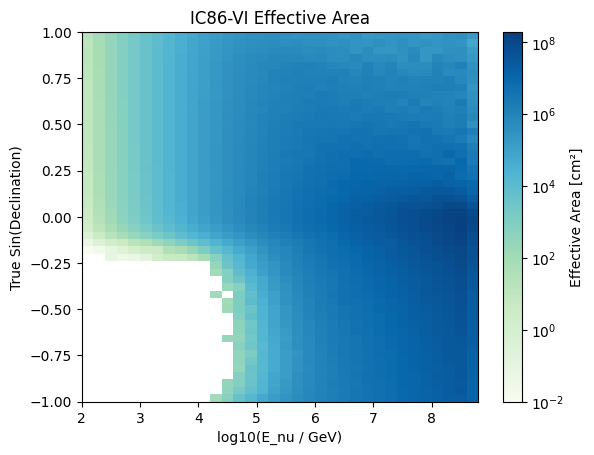

In [19]:
plt.pcolormesh(log_10_enu_edges, sin_nu_dec, eff_area, cmap='GnBu', norm=LogNorm())
plt.title('IC86-VI Effective Area')
plt.colorbar(label='Effective Area [cm²]')
plt.xlabel('log10(E_nu / GeV)')
plt.ylabel('True Sin(Declination)')
plt.show()

``effective_area.get_detection_prob_for_decnu`` returns the detection probability for each neutrino declination for a certain given true energy range. 

In [17]:
detection_prob = np.array(
    [effective_area.get_detection_prob_for_decnu(i, enu[0], enu[10], enu[0], enu[-1]) for i in nu_dec]
)